# ANN untuk Prediksi Pendapatan Pelanggan (Business Intelligence)

Notebook ini adalah awalan untuk mengolah data bisnis, melatih model Artificial Neural Network (ANN), mengevaluasi performa, dan menghasilkan insight manajerial.

Dataset yang digunakan (di repo yang sama): `ann_business_intelligence_dataset.csv`

## 1) Import library

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

## 2) Load dataset

Shape: (500, 9)


,Customer_ID,Age,City,Number_of_Transactions,Average_Transaction_Value,Favorite_Product_Category,Monthly_Purchase_Frequency,Months_as_Customer,Total_Revenue
0,CUST1000,56,Jakarta,11,387000.0,Electronics,3.26,9,1342514.96
1,CUST1001,46,Denpasar,5,392000.0,Books,1.46,12,246830.94
2,CUST1002,32,Bandung,12,342000.0,Fashion,4.73,44,1626808.59
3,CUST1003,60,Bandung,10,527000.0,Books,0.53,38,211182.40
4,CUST1004,25,Denpasar,14,287000.0,Fashion,3.98,19,1185758.82


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_ID                 500 non-null    object 
 1   Age                         500 non-null    int64  
 2   City                        500 non-null    object 
 3   Number_of_Transactions      500 non-null    int64  
 4   Average_Transaction_Value   500 non-null    float64
 5   Favorite_Product_Category   500 non-null    object 
 6   Monthly_Purchase_Frequency  500 non-null    float64
 7   Months_as_Customer          500 non-null    int64  
 8   Total_Revenue               500 non-null    float64
dtypes: float64(3), int64(3), object(3)
memory usage: 35.3+ KB


None

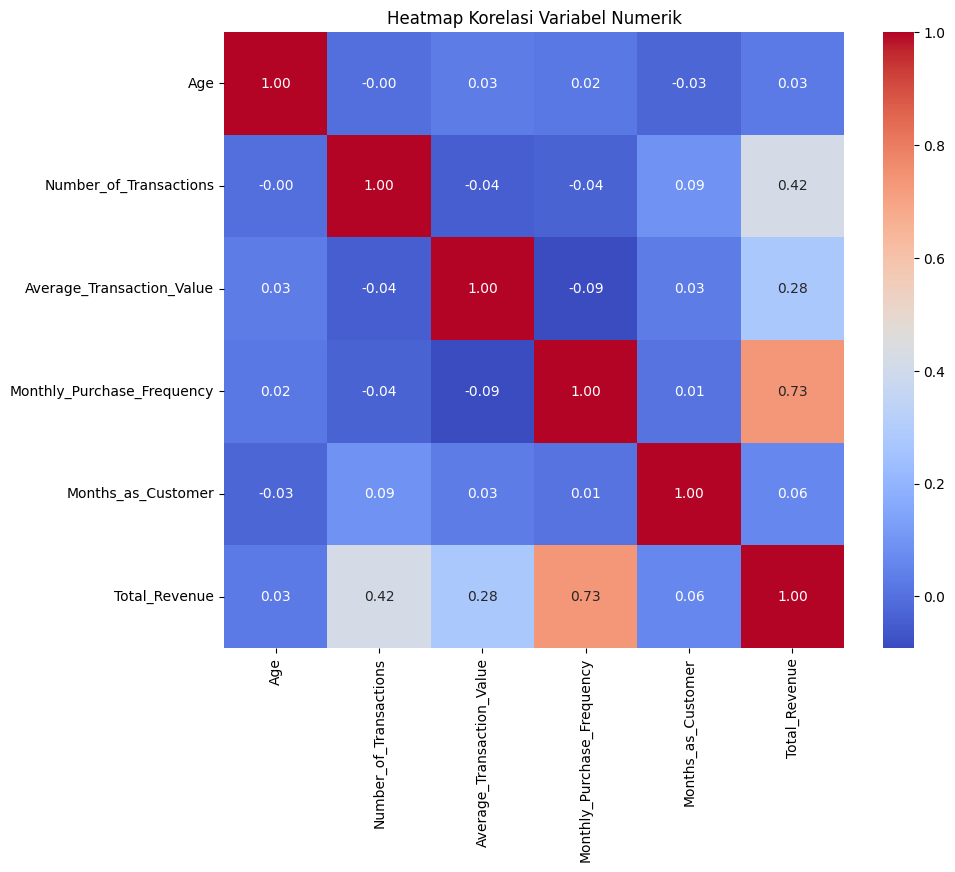

In [2]:
DATA_PATH = Path('ann_business_intelligence_dataset.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Dataset tidak ditemukan: {DATA_PATH}. Tambahkan file ke root repo terlebih dahulu.'
    )

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
display(df.info())

plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Variabel Numerik')
plt.show()

## 3) Data cleaning & preprocessing

In [3]:
target_col = 'Total_Revenue'
required_columns = [
    'Customer_ID',
    'Age',
    'City',
    'Number_of_Transactions',
    'Average_Transaction_Value',
    'Favorite_Product_Category',
    'Monthly_Purchase_Frequency',
    'Months_as_Customer',
    target_col,
]

missing_cols = [c for c in required_columns if c not in df.columns]
if missing_cols:
    raise ValueError(f'Kolom wajib tidak lengkap: {missing_cols}')

# Membuat fitur terkait Estimasi Total Pengeluaran Historis
df['Estimated_Historical_Spend'] = df['Number_of_Transactions'] * df['Average_Transaction_Value']

df = df[df[target_col] >= 0].copy()

# Drop ID karena bukan sinyal perilaku bisnis
X = df.drop(columns=[target_col, 'Customer_ID']).copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train_transformed = np.log1p(y_train)
y_test_transformed = np.log1p(y_test)

y_train_array = y_train_transformed.values
y_test_array = y_test_transformed.values

numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numeric_features),
        ('cat', cat_pipeline, categorical_features),
    ]
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

if hasattr(X_train_prep, 'toarray'):
    X_train_prep = X_train_prep.toarray()
    X_test_prep = X_test_prep.toarray()

print('Train shape (setelah preprocessing):', X_train_prep.shape)
print('Test shape  (setelah preprocessing):', X_test_prep.shape)

Train shape (setelah preprocessing): (396, 16)
Test shape  (setelah preprocessing): (100, 16)


## 4) Bangun & latih model ANN (Keras/TensorFlow)

In [4]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

y_train_array = y_train_transformed.values if hasattr(y_train_transformed, 'values') else y_train_transformed
y_test_array = y_test_transformed.values if hasattr(y_test_transformed, 'values') else y_test_transformed

model = Sequential([
    Input(shape=(X_train_prep.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_prep,
    y_train_array,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 185.0129 - mae: 13.5842 - val_loss: 174.1680 - val_mae: 13.1803
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 166.3366 - mae: 12.8771 - val_loss: 156.1799 - val_mae: 12.4778
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 148.6273 - mae: 12.1653 - val_loss: 137.5664 - val_mae: 11.7036
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 128.6164 - mae: 11.3018 - val_loss: 116.9834 - val_mae: 10.7787
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 108.0325 - mae: 10.3332 - val_loss: 94.0773 - val_mae: 9.6391
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 82.1343 - mae: 8.9561 - val_loss: 69.5296 - val_mae: 8.2352
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 57.8009 - mae: 7.4043 - val_loss: 45.5993 - val_mae: 6.5683
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 35.4321 - mae: 5.5977 - val_loss: 25.6471 - val_mae: 4.7338
Epoch 9/100
10/10 ━━━━

## 5) Evaluasi model (MAE, RMSE, R²)

In [5]:
y_pred_transformed = model.predict(X_test_prep)
y_pred = np.expm1(y_pred_transformed).ravel()

y_test_asli = y_test.values if hasattr(y_test, 'values') else y_test

mae = mean_absolute_error(y_test_asli, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_asli, y_pred))
r2 = r2_score(y_test_asli, y_pred)
mape = mean_absolute_percentage_error(y_test_asli, y_pred)

print("\n--- HASIL EVALUASI MODEL ---")
print(f"MAE  : Rp {mae:,.2f}")
print(f"RMSE : Rp {rmse:,.2f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2%}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

--- HASIL EVALUASI MODEL ---
MAE  : Rp 343,411.93
RMSE : Rp 462,444.31
R²   : 0.0504
MAPE : 96.16%


## 6) Visualisasi hasil

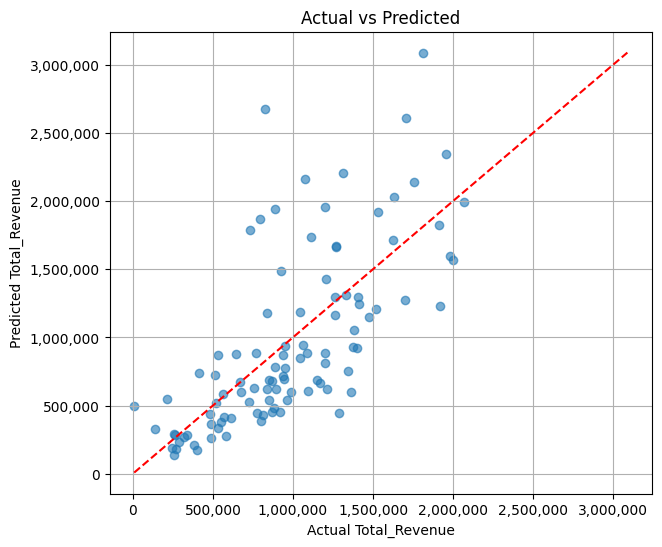

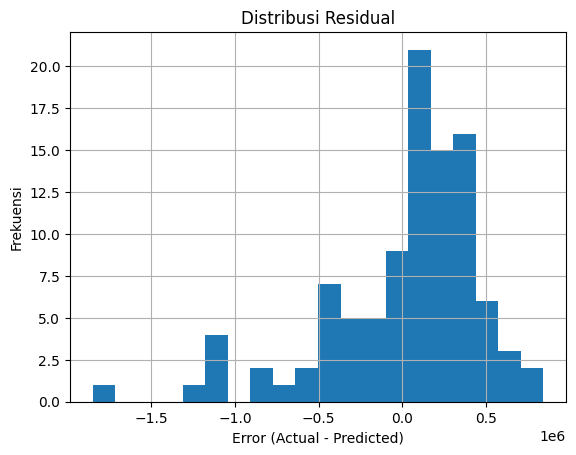

In [6]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_asli, y_pred, alpha=0.6)
min_val = min(y_test_asli.min(), y_pred.min())
max_val = max(y_test_asli.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel('Actual Total_Revenue')
plt.ylabel('Predicted Total_Revenue')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.show()

residuals = y_test_asli - y_pred
plt.hist(residuals, bins=20)
plt.title('Distribusi Residual')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frekuensi')
plt.grid(True)
plt.show()

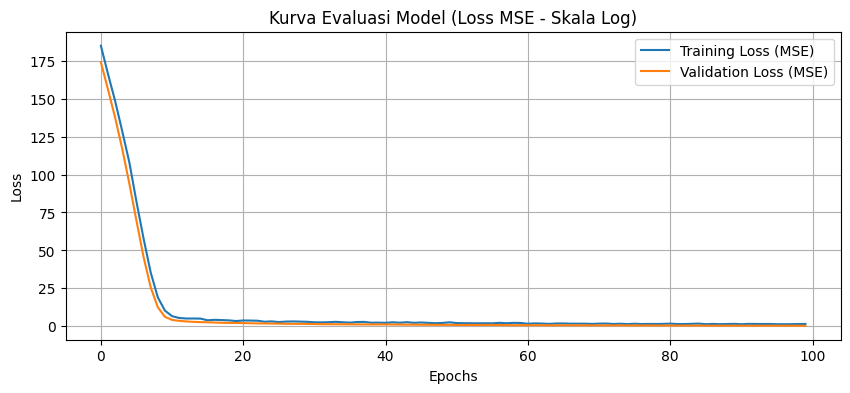

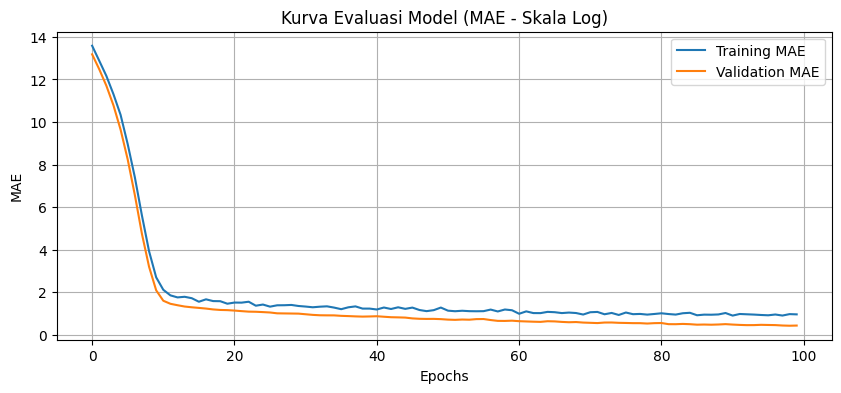

In [7]:
# Visualisasi Kurva Loss MSE
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Kurva Evaluasi Model (Loss MSE - Skala Log)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Visualisasi Kurva MAE
plt.figure(figsize=(10, 4))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Kurva Evaluasi Model (MAE - Skala Log)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

## 7) Insight bisnis awal

In [8]:
result = X_test.copy()
result['actual_revenue'] = y_test_asli
result['predicted_revenue'] = y_pred
result['prediction_error'] = result['actual_revenue'] - result['predicted_revenue']

print('Top 5 pelanggan dengan prediksi revenue tertinggi (subset test):')
display(result.sort_values('predicted_revenue', ascending=False).head(5))

pd.options.display.float_format = '{:,.2f}'.format

print('Rata-rata revenue prediksi per kota:')
avg_city = result.groupby('City', as_index=False)['predicted_revenue'].mean().sort_values('predicted_revenue', ascending=False)
display(avg_city)

Top 5 pelanggan dengan prediksi revenue tertinggi (subset test):


,Age,City,Number_of_Transactions,Average_Transaction_Value,Favorite_Product_Category,Monthly_Purchase_Frequency,Months_as_Customer,Estimated_Historical_Spend,actual_revenue,predicted_revenue,prediction_error
461,64,Jakarta,12,319000.0,Fashion,4.89,14,3828000.0,1809231.26,3088261.00,-1279029.74
333,61,Surabaya,11,193000.0,Electronics,4.83,49,2123000.0,823148.01,2672679.75,-1849531.74
55,64,Jakarta,17,312000.0,Fashion,4.04,55,5304000.0,1705895.65,2606908.25,-901012.60
68,43,Denpasar,10,541000.0,Groceries,4.37,31,5410000.0,1957576.08,2343177.50,-385601.42
323,47,Denpasar,15,260000.0,Books,4.22,1,3900000.0,1312451.59,2203055.50,-890603.91


Rata-rata revenue prediksi per kota:


,City,predicted_revenue
2,Jakarta,"1,168,189.50"
0,Bandung,"1,006,525.19"
4,Surabaya,"946,899.25"
3,Medan,"915,670.62"
1,Denpasar,"853,791.00"
